In [1]:
# Install and import required packages
!pip install -q kagglehub

import os
import random
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
from torchvision.utils import save_image

# Download latest version of Selfie2Anime
import kagglehub
dataset_path = kagglehub.dataset_download("arnaud58/selfie2anime")
print("Path to dataset files:", dataset_path)

Mounting files to /kaggle/input/datasets/arnaud58/selfie2anime...
Path to dataset files: /kaggle/input/datasets/arnaud58/selfie2anime


## Hyperparameters and Configuration

In [3]:
class Config:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    TRAIN_DIR_A = os.path.join(dataset_path, "trainA")
    TRAIN_DIR_B = os.path.join(dataset_path, "trainB")
    VAL_DIR_A = os.path.join(dataset_path, "testA")
    VAL_DIR_B = os.path.join(dataset_path, "testB")
    
    BATCH_SIZE = 1
    LEARNING_RATE = 2e-4
    LAMBDA_CYCLE = 10.0
    LAMBDA_IDENTITY = 5.0
    NUM_EPOCHS = 35
    IMAGE_SIZE = 256
    LOAD_MODEL = False
    SAVE_MODEL = True
    CHECKPOINT_GEN_H = "genh.pth.tar" # Human -> Anime
    CHECKPOINT_GEN_A = "gena.pth.tar" # Anime -> Human
    CHECKPOINT_CRITIC_H = "critich.pth.tar"
    CHECKPOINT_CRITIC_A = "critica.pth.tar"

print(f"Using pipeline configuration on device: {Config.DEVICE}")

Using pipeline configuration on device: cuda


## Unpaired Custom Dataset Loader

In [4]:
class UnpairedDataset(torch.utils.data.Dataset):
    def __init__(self, root_human, root_anime, transform=None):
        self.root_human = root_human
        self.root_anime = root_anime
        self.transform = transform

        self.human_images = os.listdir(root_human)
        self.anime_images = os.listdir(root_anime)
        self.length_dataset = max(len(self.human_images), len(self.anime_images))
        self.human_len = len(self.human_images)
        self.anime_len = len(self.anime_images)

    def __len__(self):
        return self.length_dataset

    def __getitem__(self, index):
        human_img = self.human_images[index % self.human_len]
        anime_img = self.anime_images[index % self.anime_len]

        human_path = os.path.join(self.root_human, human_img)
        anime_path = os.path.join(self.root_anime, anime_img)

        human_img = Image.open(human_path).convert("RGB")
        anime_img = Image.open(anime_path).convert("RGB")

        if self.transform:
            human_img = self.transform(human_img)
            anime_img = self.transform(anime_img)

        return human_img, anime_img

# Transformations for data preparation and augmentation
transforms_pipeline = transforms.Compose([
    transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE), Image.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Initialize DataLoaders
train_dataset = UnpairedDataset(Config.TRAIN_DIR_A, Config.TRAIN_DIR_B, transform=transforms_pipeline)
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, pin_memory=True)

val_dataset = UnpairedDataset(Config.VAL_DIR_A, Config.VAL_DIR_B, transform=transforms_pipeline)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, pin_memory=True)

print(f"Dataset Loaded successfully! Number of batches: {len(train_loader)}")

Dataset Loaded successfully! Number of batches: 3400


## PatchGAN Discriminator Architecture

In [5]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, stride, 1, bias=False, padding_mode="reflect"),
            nn.InstanceNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class Discriminator(nn.Module):
    def __init__(self, in_channels=3, features=[64, 128, 256, 512]):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, features[0], kernel_size=4, stride=2, padding=1, padding_mode="reflect"),
            nn.LeakyReLU(0.2, inplace=True)
        )
        layers = []
        in_channels = features[0]
        for feature in features[1:]:
            layers.append(CNNBlock(in_channels, feature, stride=1 if feature == features[-1] else 2))
            in_channels = feature
        
        layers.append(nn.Conv2d(in_channels, 1, kernel_size=4, stride=1, padding=1, padding_mode="reflect"))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = self.initial(x)
        return torch.sigmoid(self.model(x))

## ResNet Generator Architecture && Network Initialization & Optimization Setup

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, use_act=True, **kwargs):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, padding_mode="reflect", **kwargs) if down
            else nn.ConvTranspose2d(in_channels, out_channels, **kwargs),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True) if use_act else nn.Identity()
        )
    def forward(self, x):
        return self.conv(x)

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            ConvBlock(channels, channels, kernel_size=3, padding=1),
            ConvBlock(channels, channels, use_act=False, kernel_size=3, padding=1)
        )
    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, img_channels=3, num_features=64, num_residuals=9):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(img_channels, num_features, kernel_size=7, stride=1, padding=3, padding_mode="reflect"),
            nn.InstanceNorm2d(num_features),
            nn.ReLU(inplace=True)
        )
        self.down_blocks = nn.ModuleList([
            ConvBlock(num_features, num_features*2, kernel_size=3, stride=2, padding=1),
            ConvBlock(num_features*2, num_features*4, kernel_size=3, stride=2, padding=1)
        ])
        self.res_blocks = nn.Sequential(*[ResidualBlock(num_features*4) for _ in range(num_residuals)])
        self.up_blocks = nn.ModuleList([
            ConvBlock(num_features*4, num_features*2, down=False, kernel_size=3, stride=2, padding=1, output_padding=1),
            ConvBlock(num_features*2, num_features, down=False, kernel_size=3, stride=2, padding=1, output_padding=1)
        ])
        self.last = nn.Conv2d(num_features, img_channels, kernel_size=7, stride=1, padding=3, padding_mode="reflect")

    def forward(self, x):
        x = self.initial(x)
        for block in self.down_blocks:
            x = block(x)
        x = self.res_blocks(x)
        for block in self.up_blocks:
            x = block(x)
        return torch.tanh(self.last(x))

In [7]:
# Initialize Networks
gen_A = Generator(img_channels=3, num_features=64, num_residuals=9).to(Config.DEVICE) # Photo -> Cartoon
gen_H = Generator(img_channels=3, num_features=64, num_residuals=9).to(Config.DEVICE) # Cartoon -> Photo
critic_A = Discriminator(in_channels=3).to(Config.DEVICE)
critic_H = Discriminator(in_channels=3).to(Config.DEVICE)

# Optimizers
opt_disc = optim.Adam(
    list(critic_A.parameters()) + list(critic_H.parameters()),
    lr=Config.LEARNING_RATE,
    betas=(0.5, 0.999),
)
opt_gen = optim.Adam(
    list(gen_A.parameters()) + list(gen_H.parameters()),
    lr=Config.LEARNING_RATE,
    betas=(0.5, 0.999),
)

# Loss functions
L1 = nn.L1Loss() # Used for Cycle and Identity evaluation
mse = nn.MSELoss() # Used for Adversarial target tracking

# Directories to output intermediate validation transformations
os.makedirs("saved_images", exist_ok=True)
print("Networks initialized and ready for training initialization.")

Networks initialized and ready for training initialization.


## Complete Adversarial Training Loop

In [8]:
import random
import os
import torch
from torch.optim.lr_scheduler import LambdaLR
from torchvision.utils import save_image

# ---------------------------------------------------------
# NEW IMPLEMENTATION: Checkpoint Management Utility
# ---------------------------------------------------------
def save_checkpoint(model, optimizer, filename="checkpoint.pth.tar"):
    """
    Saves model weights and optimizer states securely to Kaggle Workspace output.
    """
    print(f"==> Saving checkpoint to: {filename}")
    
    # Secure parent directory paths if subdirectories are used
    dir_name = os.path.dirname(filename)
    if dir_name and not os.path.exists(dir_name):
        os.makedirs(dir_name, exist_ok=True)
        
    checkpoint = {
        "state_dict": model.state_dict(),
        "optimizer": optimizer.state_dict(),
    }
    torch.save(checkpoint, filename)


# ---------------------------------------------------------
# QUALITY UPGRADE: Image History Buffer (Replay Buffer)
# ---------------------------------------------------------
class ImageBuffer:
    """
    Stores previously generated images to inject historical context 
    into discriminator updates. Prevents the model from oscillating.
    """
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def query(self, images):
        if self.max_size == 0:
            return images
        return_images = []
        for image in images:
            image = torch.unsqueeze(image.data, 0)
            if len(self.data) < self.max_size:
                self.data.append(image)
                return_images.append(image)
            else:
                if random.uniform(0, 1) > 0.5:
                    random_id = random.randint(0, self.max_size - 1)
                    keep_image = self.data[random_id].clone()
                    self.data[random_id] = image
                    return_images.append(keep_image)
                else:
                    return_images.append(image)
        return torch.cat(return_images, 0)

# Initialize History Buffers
pool_anime = ImageBuffer(max_size=50)
pool_human = ImageBuffer(max_size=50)


# ---------------------------------------------------------
# SPEED UPGRADE: Modernized Mixed Precision Scalers (AMP)
# ---------------------------------------------------------
# Swapped out deprecated torch.cuda.amp for modern torch.amp
device_type = "cuda" if torch.cuda.is_available() else "cpu"
scaler_gen = torch.amp.GradScaler(device_type)
scaler_disc = torch.amp.GradScaler(device_type)


# ---------------------------------------------------------
# OPTIMIZED TRAINING FUNCTION
# ---------------------------------------------------------
def train_fn(critic_A, critic_H, gen_H, gen_A, loader, opt_disc, opt_gen, l1, mse, epoch, scaler_disc, scaler_gen, pool_A, pool_H):
    running_g_loss = 0.0  
    device_type = "cuda" if torch.cuda.is_available() else "cpu"
    
    for idx, (human, anime) in enumerate(loader):
        human = human.to(Config.DEVICE)
        anime = anime.to(Config.DEVICE)

        # -------------------------------
        #  TRAIN DISCRIMINATORS (CRITICS)
        # -------------------------------
        with torch.amp.autocast(device_type):
            fake_anime = gen_A(human)
            fake_anime_buffered = pool_A.query(fake_anime)
            critic_A_real = critic_A(anime)
            critic_A_fake = critic_A(fake_anime_buffered.detach())
            
            # One-Sided Label Smoothing (Real targets = 0.9 instead of 1.0)
            real_label_A = torch.full_like(critic_A_real, 0.9)
            fake_label_A = torch.zeros_like(critic_A_fake)
            critic_A_loss = mse(critic_A_real, real_label_A) + mse(critic_A_fake, fake_label_A)

            fake_human = gen_H(anime)
            fake_human_buffered = pool_H.query(fake_human)
            critic_H_real = critic_H(human)
            critic_H_fake = critic_H(fake_human_buffered.detach())
            
            # One-Sided Label Smoothing (Real targets = 0.9 instead of 1.0)
            real_label_H = torch.full_like(critic_H_real, 0.9)
            fake_label_H = torch.zeros_like(critic_H_fake)
            critic_H_loss = mse(critic_H_real, real_label_H) + mse(critic_H_fake, fake_label_H)

            disc_loss = (critic_A_loss + critic_H_loss) / 2

        opt_disc.zero_grad()
        scaler_disc.scale(disc_loss).backward()
        scaler_disc.step(opt_disc)
        scaler_disc.update()

        # -------------------------------
        #  TRAIN GENERATORS
        # -------------------------------
        with torch.amp.autocast(device_type):
            # Adversarial Loss
            critic_A_fake = critic_A(fake_anime)
            critic_H_fake = critic_H(fake_human)
            loss_G_A = mse(critic_A_fake, torch.ones_like(critic_A_fake))
            loss_G_H = mse(critic_H_fake, torch.ones_like(critic_H_fake))

            # Cycle-Consistency Loss
            cycle_human = gen_H(fake_anime)
            cycle_anime = gen_A(fake_human)
            cycle_human_loss = l1(human, cycle_human)
            cycle_anime_loss = l1(anime, cycle_anime)

            # Identity Loss
            id_human = gen_H(human)
            id_anime = gen_A(anime)
            id_human_loss = l1(human, id_human)
            id_anime_loss = l1(anime, id_anime)

            # Total Loss Equation
            g_loss = (
                loss_G_A + loss_G_H
                + (cycle_human_loss * Config.LAMBDA_CYCLE)
                + (cycle_anime_loss * Config.LAMBDA_CYCLE)
                + (id_human_loss * Config.LAMBDA_IDENTITY)
                + (id_anime_loss * Config.LAMBDA_IDENTITY)
            )

        opt_gen.zero_grad()
        scaler_gen.scale(g_loss).backward()
        scaler_gen.step(opt_gen)
        scaler_gen.update()
        
        running_g_loss += g_loss.item()

        if idx % 200 == 0:
            print(f"Epoch [{epoch}/{Config.NUM_EPOCHS}] Batch [{idx}/{len(loader)}] Loss D: {disc_loss.item():.4f} Loss G: {g_loss.item():.4f}")
            
    return running_g_loss / len(loader)


# ---------------------------------------------------------
# QUALITY UPGRADE: Linear Learning Rate Decay Schedule
# ---------------------------------------------------------
lr_decay_rule = lambda ep: 1.0 if ep < 50 else 1.0 - (ep - 50) / (Config.NUM_EPOCHS - 50)

scheduler_gen = LambdaLR(opt_gen, lr_lambda=lr_decay_rule)
scheduler_disc = LambdaLR(opt_disc, lr_lambda=lr_decay_rule)


# --- Execution Pipeline with Best Model Checkpointing ---
best_g_loss = float('inf')
print("Starting high-performance optimized training tracking layout...")

for epoch in range(Config.NUM_EPOCHS):
    avg_epoch_g_loss = train_fn(
        critic_A, critic_H, gen_H, gen_A, train_loader, 
        opt_disc, opt_gen, L1, mse, epoch, 
        scaler_disc, scaler_gen, pool_anime, pool_human
    )
    
    scheduler_gen.step()
    scheduler_disc.step()
    
    current_lr = opt_gen.param_groups[0]['lr']
    print(f"==> Epoch {epoch} Complete. Avg G Loss: {avg_epoch_g_loss:.4f} | Current LR: {current_lr:.6f}")
    
    if avg_epoch_g_loss < best_g_loss:
        best_g_loss = avg_epoch_g_loss
        print(f" New Best Performance Detected! (Loss: {best_g_loss:.4f})")
        
        if Config.SAVE_MODEL:
            save_checkpoint(gen_A, opt_gen, filename="best_" + Config.CHECKPOINT_GEN_A)
            save_checkpoint(gen_H, opt_gen, filename="best_" + Config.CHECKPOINT_GEN_H)
            save_checkpoint(critic_A, opt_disc, filename="best_" + Config.CHECKPOINT_CRITIC_A)
            save_checkpoint(critic_H, opt_disc, filename="best_" + Config.CHECKPOINT_CRITIC_H)
    
    # Save visual validation snapshots every 2 epochs
    if epoch % 2 == 0:
        for idx, (h, a) in enumerate(val_loader):
            h = h.to(Config.DEVICE)
            with torch.no_grad():
                with torch.amp.autocast(device_type):
                    fake_a = gen_A(h)
                save_image(fake_a * 0.5 + 0.5, f"saved_images/epoch_{epoch}_val_{idx}.png")
            if idx == 4: 
                break

Starting high-performance optimized training tracking layout...
Epoch [0/35] Batch [0/3400] Loss D: 0.4192 Loss G: 15.2296
Epoch [0/35] Batch [200/3400] Loss D: 0.3351 Loss G: 10.5715
Epoch [0/35] Batch [400/3400] Loss D: 0.2592 Loss G: 6.0722
Epoch [0/35] Batch [600/3400] Loss D: 0.3457 Loss G: 6.7078
Epoch [0/35] Batch [800/3400] Loss D: 0.1374 Loss G: 6.5336
Epoch [0/35] Batch [1000/3400] Loss D: 0.2896 Loss G: 8.5766
Epoch [0/35] Batch [1200/3400] Loss D: 0.4356 Loss G: 7.0789
Epoch [0/35] Batch [1400/3400] Loss D: 0.3827 Loss G: 10.6435
Epoch [0/35] Batch [1600/3400] Loss D: 0.2107 Loss G: 5.8390
Epoch [0/35] Batch [1800/3400] Loss D: 0.1421 Loss G: 6.9030
Epoch [0/35] Batch [2000/3400] Loss D: 0.2393 Loss G: 7.9667
Epoch [0/35] Batch [2200/3400] Loss D: 0.1587 Loss G: 5.4364
Epoch [0/35] Batch [2400/3400] Loss D: 0.2148 Loss G: 6.0721
Epoch [0/35] Batch [2600/3400] Loss D: 0.1618 Loss G: 6.7359
Epoch [0/35] Batch [2800/3400] Loss D: 0.3042 Loss G: 7.4740
Epoch [0/35] Batch [3000/

## Loss D: 0.4192 Loss G: 15.2296  -  LOSS = 7.1613

## Model File Download into the PC

In [9]:
import os
import zipfile
from IPython.display import FileLink, display, HTML

def auto_download_best_weights(zip_name="cyclegan_best_weights.zip"):
    """
    Zips your 'best_' model files and injects JavaScript to force 
    an automatic browser download directly to your PC.
    """
    # 1. Target only the optimized 'best_' pth.tar files generated by your loop
    checkpoint_files = [f for f in os.listdir('.') if f.startswith('best_') and f.endswith('.pth.tar')]
    
    if not checkpoint_files:
        print("❌ Error: No files starting with 'best_' were found in /kaggle/working/.")
        print("👉 Ensure your training loop successfully saved at least one checkpoint before running this.")
        return

    print(f"📦 Found {len(checkpoint_files)} optimized checkpoint files. Archiving...")
    
    # 2. Compress the files into a single zip archive
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file in checkpoint_files:
            zipf.write(file)
            print(f"   -> Successfully archived: {file}")
            
    print("\n" + "="*50)
    print("🎉 ARCHIVE CREATED SUCCESSFULLY!")
    print("🚀 Attempting to force automatic browser download...")
    print("="*50 + "\n")
    
    # 3. Display the standard Kaggle clickable link as a manual fallback
    fallback_link = FileLink(zip_name)
    display(fallback_link)
    
    # 4. Inject JavaScript to find the rendered HTML link and programmatically click it
    js_automation_script = f"""
    <script>
    setTimeout(function() {{
        var anchors = document.querySelectorAll('a');
        for (var i = 0; i < anchors.length; i++) {{
            var href = anchors[i].getAttribute('href');
            if (href && href.includes('{zip_name}')) {{
                anchors[i].click();
                console.log('Automatic download triggered for: ' + '{zip_name}');
                break;
            }}
        }}
    }}, 1500); // 1.5 second delay to ensure the DOM elements have fully rendered
    </script>
    """
    display(HTML(js_automation_script))

# Run the automated download process
auto_download_best_weights()

📦 Found 4 optimized checkpoint files. Archiving...
   -> Successfully archived: best_critich.pth.tar
   -> Successfully archived: best_critica.pth.tar
   -> Successfully archived: best_gena.pth.tar
   -> Successfully archived: best_genh.pth.tar

🎉 ARCHIVE CREATED SUCCESSFULLY!
🚀 Attempting to force automatic browser download...



/kaggle/working/cyclegan_best_weights.zip

# Testing and Evaluation**

--- Initializing Test Option A ---
Found 100 images in validation folder: /kaggle/input/datasets/arnaud58/selfie2anime/testA
Step 1: Starting inference function...
Step 2: Loading model weights from best_gena.pth.tar...
Step 3: Transforming input image...
Step 4: Running forward pass on device: cuda...
Step 5: Denormalizing data structures...
📊 Original Array Shape: (256, 256, 3) | Min Val: 0.00 | Max Val: 1.00
📊 Cartoon Array Shape: (256, 256, 3) | Min Val: 0.01 | Max Val: 1.00
Step 6: Triggering Matplotlib rendering engine...


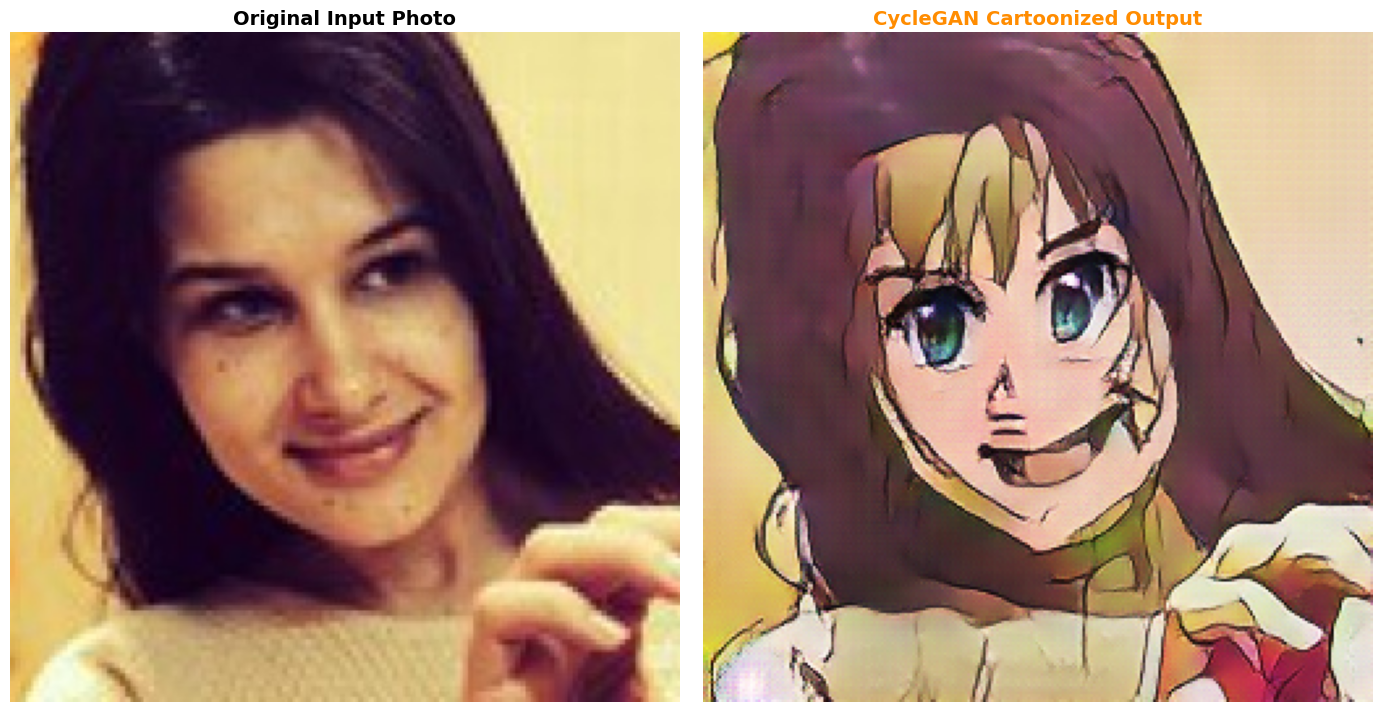

✨ Cell execution finished completely!


In [14]:
import os
import glob
import random
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

def run_pipeline_inference(image_path, weights_path="best_gena.pth.tar"):
    print("Step 1: Starting inference function...")
    
    if not os.path.exists(weights_path):
        print(f"❌ Error: Weights file '{weights_path}' not found.")
        return
        
    if not os.path.exists(image_path):
        print(f"❌ Error: Input image path '{image_path}' does not exist.")
        return

    print(f"Step 2: Loading model weights from {weights_path}...")
    model = Generator(img_channels=3, num_features=64, num_residuals=9).to(Config.DEVICE)
    checkpoint = torch.load(weights_path, map_location=Config.DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    inference_transforms = transforms.Compose([
        transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE), Image.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])

    print("Step 3: Transforming input image...")
    raw_img = Image.open(image_path).convert("RGB")
    input_tensor = inference_transforms(raw_img).unsqueeze(0).to(Config.DEVICE)

    print(f"Step 4: Running forward pass on device: {Config.DEVICE}...")
    with torch.no_grad():
        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            output_tensor = model(input_tensor)

    print("Step 5: Denormalizing data structures...")
    input_tensor = input_tensor.squeeze(0).cpu().float() * 0.5 + 0.5
    output_tensor = output_tensor.squeeze(0).cpu().float() * 0.5 + 0.5

    input_tensor = torch.clamp(input_tensor, 0, 1)
    output_tensor = torch.clamp(output_tensor, 0, 1)

    original_np = input_tensor.permute(1, 2, 0).numpy()
    cartoon_np = output_tensor.permute(1, 2, 0).numpy()

    # DIAGNOSTIC CHECK: Print data array properties
    print(f"📊 Original Array Shape: {original_np.shape} | Min Val: {original_np.min():.2f} | Max Val: {original_np.max():.2f}")
    print(f"📊 Cartoon Array Shape: {cartoon_np.shape} | Min Val: {cartoon_np.min():.2f} | Max Val: {cartoon_np.max():.2f}")

    print("Step 6: Triggering Matplotlib rendering engine...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    axes[0].imshow(original_np)
    axes[0].set_title("Original Input Photo", fontsize=14, fontweight='bold')
    axes[0].axis("off")
    
    axes[1].imshow(cartoon_np)
    axes[1].set_title("CycleGAN Cartoonized Output", fontsize=14, fontweight='bold', color='darkorange')
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    print("✨ Cell execution finished completely!")

# --- Execute ---
print("--- Initializing Test Option A ---")
val_images = glob.glob(os.path.join(Config.VAL_DIR_A, "*.*"))
print(f"Found {len(val_images)} images in validation folder: {Config.VAL_DIR_A}")

if val_images:
    random_sample_path = random.choice(val_images)
    run_pipeline_inference(image_path=random_sample_path, weights_path="best_gena.pth.tar")
else:
    print("❌ Could not locate validation files split directory matching configuration targets.")

In [15]:
%matplotlib inline
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. Define Dashboard UI Elements ---
uploader = widgets.FileUpload(
    accept='image/*', 
    multiple=False, 
    description='📁 Choose Photo'
)

btn_cartoonize = widgets.Button(
    description='Cartoonize Image', 
    button_style='success',
    icon='magic'
)

output_container = widgets.Output()

# --- 2. Core Inference Engine Function ---
def process_and_display_image(image_path, weights_path="best_gena.pth.tar"):
    """Loads weights, processes the uploaded image, and plots the result."""
    if not os.path.exists(weights_path):
        print(f"❌ Error: Weights file '{weights_path}' not found in this directory.")
        return

    # Initialize Generator matching your network design
    model = Generator(img_channels=3, num_features=64, num_residuals=9).to(Config.DEVICE)
    checkpoint = torch.load(weights_path, map_location=Config.DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    # Preprocessing pipeline
    inference_transforms = transforms.Compose([
        transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE), Image.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])

    # Load image
    raw_img = Image.open(image_path).convert("RGB")
    input_tensor = inference_transforms(raw_img).unsqueeze(0).to(Config.DEVICE)

    # Forward pass
    with torch.no_grad():
        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            output_tensor = model(input_tensor)

    # Denormalize & cast strictly to float32 for Matplotlib compatibility
    input_tensor = input_tensor.squeeze(0).cpu().float() * 0.5 + 0.5
    output_tensor = output_tensor.squeeze(0).cpu().float() * 0.5 + 0.5

    # Clamp boundaries between [0, 1] to avoid color distortion artifacts
    input_tensor = torch.clamp(input_tensor, 0, 1)
    output_tensor = torch.clamp(output_tensor, 0, 1)

    # Convert to NumPy layout (H, W, C)
    original_np = input_tensor.permute(1, 2, 0).numpy()
    cartoon_np = output_tensor.permute(1, 2, 0).numpy()

    # Display side-by-side visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    axes[0].imshow(original_np)
    axes[0].set_title("Original Input Photo", fontsize=14, fontweight='bold')
    axes[0].axis("off")
    
    axes[1].imshow(cartoon_np)
    axes[1].set_title("CycleGAN Cartoonized Output", fontsize=14, fontweight='bold', color='darkorange')
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

# --- 3. UI Button Click Event Handler ---
def on_button_clicked(b):
    with output_container:
        clear_output() # Clears previous results on repeated runs
        
        # Check if user actually uploaded a file
        if not uploader.value:
            print("⚠️ Please click 'Choose Photo' to select an image from your computer first!")
            return
            
        print("⏳ Parsing uploaded file and running CycleGAN inference...")
        
        try:
            # Safely extract image bytes regardless of ipywidgets version format
            uploaded_file = uploader.value[0]
            if isinstance(uploaded_file, dict):
                file_content = uploaded_file['content']
            else:
                file_content = uploaded_file.content
                
            # Write bytes to a local temporary workspace file
            temp_path = "user_input_image.jpg"
            with open(temp_path, "wb") as f:
                f.write(file_content)
                
        except Exception as e:
            print(f"❌ Error handling file conversion: {e}")
            return

        # Run the full pipeline function on the temporary file
        try:
            process_and_display_image(temp_path, weights_path="best_gena.pth.tar")
        except Exception as e:
            print(f"❌ Execution Error: {e}")
            print("👉 Check that Generator and Config definitions are compiled in your session.")

# Link the button UI action to our execution handler
btn_cartoonize.on_click(on_button_clicked)

# --- 4. Render Dashboard View ---
dashboard = widgets.VBox([
    widgets.HTML("<h3 style='color: #ff8c00; margin-bottom: 5px;'>🎨 CycleGAN Interactive Testing Bench</h3>"),
    widgets.HTML("<p style='color: #777;'>Upload a portrait image from your computer to run the model pipeline.</p>"),
    widgets.HBox([uploader, btn_cartoonize]),
    widgets.HTML("<hr style='margin: 15px 0;'>"),
    output_container
])

display(dashboard)

In [16]:
%matplotlib inline
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. Define Dashboard UI Elements ---
uploader = widgets.FileUpload(
    accept='image/*', 
    multiple=False, 
    description='📁 Choose Photo'
)

btn_cartoonize = widgets.Button(
    description='Cartoonize Image', 
    button_style='success',
    icon='magic'
)

output_container = widgets.Output()

# --- 2. Core Inference Engine Function ---
def process_and_display_image(image_path, weights_path="best_gena.pth.tar"):
    """Loads weights, processes the uploaded image, and plots the result."""
    if not os.path.exists(weights_path):
        print(f"❌ Error: Weights file '{weights_path}' not found in this directory.")
        return

    # Initialize Generator matching your network design
    model = Generator(img_channels=3, num_features=64, num_residuals=9).to(Config.DEVICE)
    checkpoint = torch.load(weights_path, map_location=Config.DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    # Preprocessing pipeline
    inference_transforms = transforms.Compose([
        transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE), Image.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])

    # Load image
    raw_img = Image.open(image_path).convert("RGB")
    input_tensor = inference_transforms(raw_img).unsqueeze(0).to(Config.DEVICE)

    # Forward pass
    with torch.no_grad():
        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            output_tensor = model(input_tensor)

    # Denormalize & cast strictly to float32 for Matplotlib compatibility
    input_tensor = input_tensor.squeeze(0).cpu().float() * 0.5 + 0.5
    output_tensor = output_tensor.squeeze(0).cpu().float() * 0.5 + 0.5

    # Clamp boundaries between [0, 1] to avoid color distortion artifacts
    input_tensor = torch.clamp(input_tensor, 0, 1)
    output_tensor = torch.clamp(output_tensor, 0, 1)

    # Convert to NumPy layout (H, W, C)
    original_np = input_tensor.permute(1, 2, 0).numpy()
    cartoon_np = output_tensor.permute(1, 2, 0).numpy()

    # Display side-by-side visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    axes[0].imshow(original_np)
    axes[0].set_title("Original Input Photo", fontsize=14, fontweight='bold')
    axes[0].axis("off")
    
    axes[1].imshow(cartoon_np)
    axes[1].set_title("CycleGAN Cartoonized Output", fontsize=14, fontweight='bold', color='darkorange')
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

# --- 3. UI Button Click Event Handler ---
def on_button_clicked(b):
    with output_container:
        clear_output() # Clears previous results on repeated runs
        
        # Check if user actually uploaded a file
        if not uploader.value:
            print("⚠️ Please click 'Choose Photo' to select an image from your computer first!")
            return
            
        print("⏳ Parsing uploaded file and running CycleGAN inference...")
        
        try:
            # Safely extract image bytes regardless of ipywidgets version format
            uploaded_file = uploader.value[0]
            if isinstance(uploaded_file, dict):
                file_content = uploaded_file['content']
            else:
                file_content = uploaded_file.content
                
            # Write bytes to a local temporary workspace file
            temp_path = "user_input_image.jpg"
            with open(temp_path, "wb") as f:
                f.write(file_content)
                
        except Exception as e:
            print(f"❌ Error handling file conversion: {e}")
            return

        # Run the full pipeline function on the temporary file
        try:
            process_and_display_image(temp_path, weights_path="best_gena.pth.tar")
        except Exception as e:
            print(f"❌ Execution Error: {e}")
            print("👉 Check that Generator and Config definitions are compiled in your session.")

# Link the button UI action to our execution handler
btn_cartoonize.on_click(on_button_clicked)

# --- 4. Render Dashboard View ---
dashboard = widgets.VBox([
    widgets.HTML("<h3 style='color: #ff8c00; margin-bottom: 5px;'>🎨 CycleGAN Interactive Testing Bench</h3>"),
    widgets.HTML("<p style='color: #777;'>Upload a portrait image from your computer to run the model pipeline.</p>"),
    widgets.HBox([uploader, btn_cartoonize]),
    widgets.HTML("<hr style='margin: 15px 0;'>"),
    output_container
])

display(dashboard)

In [17]:
%matplotlib inline
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. Define Dashboard UI Elements ---
uploader = widgets.FileUpload(
    accept='image/*', 
    multiple=False, 
    description='📁 Choose Photo'
)

btn_cartoonize = widgets.Button(
    description='Cartoonize Image', 
    button_style='success',
    icon='magic'
)

output_container = widgets.Output()

# --- 2. Core Inference Engine Function ---
def process_and_display_image(image_path, weights_path="best_gena.pth.tar"):
    """Loads weights, processes the uploaded image, and plots the result."""
    if not os.path.exists(weights_path):
        print(f"❌ Error: Weights file '{weights_path}' not found in this directory.")
        return

    # Initialize Generator matching your network design
    model = Generator(img_channels=3, num_features=64, num_residuals=9).to(Config.DEVICE)
    checkpoint = torch.load(weights_path, map_location=Config.DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    # Preprocessing pipeline
    inference_transforms = transforms.Compose([
        transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE), Image.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])

    # Load image
    raw_img = Image.open(image_path).convert("RGB")
    input_tensor = inference_transforms(raw_img).unsqueeze(0).to(Config.DEVICE)

    # Forward pass
    with torch.no_grad():
        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            output_tensor = model(input_tensor)

    # Denormalize & cast strictly to float32 for Matplotlib compatibility
    input_tensor = input_tensor.squeeze(0).cpu().float() * 0.5 + 0.5
    output_tensor = output_tensor.squeeze(0).cpu().float() * 0.5 + 0.5

    # Clamp boundaries between [0, 1] to avoid color distortion artifacts
    input_tensor = torch.clamp(input_tensor, 0, 1)
    output_tensor = torch.clamp(output_tensor, 0, 1)

    # Convert to NumPy layout (H, W, C)
    original_np = input_tensor.permute(1, 2, 0).numpy()
    cartoon_np = output_tensor.permute(1, 2, 0).numpy()

    # Display side-by-side visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    axes[0].imshow(original_np)
    axes[0].set_title("Original Input Photo", fontsize=14, fontweight='bold')
    axes[0].axis("off")
    
    axes[1].imshow(cartoon_np)
    axes[1].set_title("CycleGAN Cartoonized Output", fontsize=14, fontweight='bold', color='darkorange')
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

# --- 3. UI Button Click Event Handler ---
def on_button_clicked(b):
    with output_container:
        clear_output() # Clears previous results on repeated runs
        
        # Check if user actually uploaded a file
        if not uploader.value:
            print("⚠️ Please click 'Choose Photo' to select an image from your computer first!")
            return
            
        print("⏳ Parsing uploaded file and running CycleGAN inference...")
        
        try:
            # Safely extract image bytes regardless of ipywidgets version format
            uploaded_file = uploader.value[0]
            if isinstance(uploaded_file, dict):
                file_content = uploaded_file['content']
            else:
                file_content = uploaded_file.content
                
            # Write bytes to a local temporary workspace file
            temp_path = "user_input_image.jpg"
            with open(temp_path, "wb") as f:
                f.write(file_content)
                
        except Exception as e:
            print(f"❌ Error handling file conversion: {e}")
            return

        # Run the full pipeline function on the temporary file
        try:
            process_and_display_image(temp_path, weights_path="best_gena.pth.tar")
        except Exception as e:
            print(f"❌ Execution Error: {e}")
            print("👉 Check that Generator and Config definitions are compiled in your session.")

# Link the button UI action to our execution handler
btn_cartoonize.on_click(on_button_clicked)

# --- 4. Render Dashboard View ---
dashboard = widgets.VBox([
    widgets.HTML("<h3 style='color: #ff8c00; margin-bottom: 5px;'>🎨 CycleGAN Interactive Testing Bench</h3>"),
    widgets.HTML("<p style='color: #777;'>Upload a portrait image from your computer to run the model pipeline.</p>"),
    widgets.HBox([uploader, btn_cartoonize]),
    widgets.HTML("<hr style='margin: 15px 0;'>"),
    output_container
])

display(dashboard)